<div style="background:linear-gradient(135deg,#1E2280 0%,#0d1045 100%);padding:44px 40px;border-radius:12px;margin-bottom:12px">
<h1 style="color:#3AB5D8;font-size:2.2rem;font-weight:800;margin:0 0 8px 0">SaaS Revenue Health & Churn Intelligence Dashboard</h1>
<p style="color:rgba(255,255,255,0.65);font-size:1rem;margin:0 0 20px 0">End-to-end SaaS analytics: Revenue · Churn · Acquisition · Customer Health · Forecasting</p>
<div style="display:flex;gap:10px;flex-wrap:wrap;margin-bottom:20px">
<span style="background:rgba(58,181,216,0.18);color:#6dcde8;padding:4px 13px;border-radius:20px;font-size:0.78rem;border:1px solid rgba(58,181,216,0.3)">10,000 Customers</span>
<span style="background:rgba(58,181,216,0.18);color:#6dcde8;padding:4px 13px;border-radius:20px;font-size:0.78rem;border:1px solid rgba(58,181,216,0.3)">6 Tables · 86,000+ Rows</span>
<span style="background:rgba(58,181,216,0.18);color:#6dcde8;padding:4px 13px;border-radius:20px;font-size:0.78rem;border:1px solid rgba(58,181,216,0.3)">2022–2024</span>
<span style="background:rgba(58,181,216,0.18);color:#6dcde8;padding:4px 13px;border-radius:20px;font-size:0.78rem;border:1px solid rgba(58,181,216,0.3)">Looker Studio Export</span>
</div>
<hr style="border:none;border-top:1px solid rgba(255,255,255,0.1);margin:0 0 16px 0"/>
<table style="color:rgba(255,255,255,0.55);font-size:0.82rem;border-collapse:collapse">
<tr><td style="padding:3px 20px 3px 0;color:#3AB5D8;font-weight:600">Author</td><td>Patience Anono — PA Data Analytics</td></tr>
<tr><td style="padding:3px 20px 3px 0;color:#3AB5D8;font-weight:600">Data</td><td>Synthetic SaaS dataset — realistic business logic, reproducible Python generation</td></tr>
<tr><td style="padding:3px 20px 3px 0;color:#3AB5D8;font-weight:600">Business question</td><td>Is this SaaS business growing efficiently — and where is recurring revenue at risk?</td></tr>
</table>
</div>

## What this notebook covers

| # | Section | Business question answered |
|:--|:--------|:--------------------------|
| 1 | Setup & Data Loading | — |
| 2 | Data Quality Check | Is the data complete and reliable? |
| 3 | Revenue Analysis | How much are we making and is it growing? |
| 4 | MRR Waterfall | Where is revenue coming from and where is it leaking? |
| 5 | Customer Analysis | How many customers do we have and how many are we losing? |
| 6 | Cohort Retention | Which customers stay the longest? |
| 7 | Acquisition Channel Analysis | Which marketing channels bring the best customers? |
| 8 | Product Usage & Engagement | Are customers actually using the product? |
| 9 | Customer Support Analysis | Are support patterns signalling churn risk? |
| 10 | Revenue at Risk | Which active accounts need attention right now? |
| 11 | Key Findings | Summary of everything the data showed |
| 12 | Looker Studio Export | Combined dataset for dashboard visualisation |

---

## 1. Setup and Data Loading

I started by importing the necessary libraries and loading all six CSV files into pandas DataFrames. Each file represents one table in the SaaS data model — customers, marketing, subscriptions, payments, product usage and support tickets.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# PA Data Analytics colour palette 
NAVY   = '#1E2280'
SKY    = '#3AB5D8'
AMBER  = '#C8891A'
GREEN  = '#1A7A4A'
RED    = '#C0392B'
ORANGE = '#D35400'
GREY   = '#ADB5BD'
MID    = '#555770'
PURPLE = '#6A0572'

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#F8F9FC',
    'axes.grid':True,'grid.color':'#E0E4EF','grid.linewidth':0.6,
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.spines.left':False,'font.family':'sans-serif','font.size':11,
    'axes.titlesize':13,'axes.titleweight':'bold','axes.titlepad':10,
    'legend.framealpha':0.9,
})

# Load all six CSV files 
# Update DATA_PATH to match where your CSV files are saved.
# Use forward slashes even on Windows — Python handles them correctly.
DATA_PATH = 'C:/Users/Patience/Documents/GITHUB/SaaS Revenue Health & Churn Intelligence Dashboard/data/raw/'

customers  = pd.read_csv(f'{DATA_PATH}customers.csv',       parse_dates=['signup_date'])
marketing  = pd.read_csv(f'{DATA_PATH}marketing.csv',       parse_dates=['conversion_date'])
subs       = pd.read_csv(f'{DATA_PATH}subscriptions.csv',   parse_dates=['start_date','end_date'])
payments   = pd.read_csv(f'{DATA_PATH}payments.csv',        parse_dates=['date'])
usage      = pd.read_csv(f'{DATA_PATH}product_usage.csv',   parse_dates=['week_start'])
tickets    = pd.read_csv(f'{DATA_PATH}support_tickets.csv', parse_dates=['created_date','closed_date'])

# Fix is_trial if it loaded as True/False strings
subs['is_trial'] = subs['is_trial'].map(
    {True:1, False:0, 1:1, 0:0, 'True':1, 'False':0}
).fillna(0).astype(int)

# Summary table
tables = {
    'customers'      : customers,
    'marketing'      : marketing,
    'subscriptions'  : subs,
    'payments'       : payments,
    'product_usage'  : usage,
    'support_tickets': tickets,
}
print(f'  {"Table":<20}  {"Rows":>8}  {"Columns":>8}')
print('  ' + '-'*40)
for name, df in tables.items():
    print(f'  {name:<20}  {len(df):>8,}  {df.shape[1]:>8}')
print(f'\n  Total rows: {sum(len(d) for d in tables.values()):,}')

# Facts the markdown explanation will reference — calculated from actual data
date_start = customers['signup_date'].min().strftime('%B %Y')
date_end   = customers['signup_date'].max().strftime('%B %Y')
years      = round((customers['signup_date'].max() - customers['signup_date'].min()).days / 365, 1)

print(f'\n  Signup date range : {date_start} to {date_end} ({years} years)')
print(f'  Unique customers  : {len(customers):,}')
print(f'  Subscription rows : {len(subs):,} — includes plan changes and cancellations')

  Table                     Rows   Columns
  ----------------------------------------
  customers               10,000         8
  marketing               10,000         8
  subscriptions           13,725         9
  payments                25,703         8
  product_usage           15,984         9
  support_tickets         10,990        10

  Total rows: 86,402

  Signup date range : January 2022 to November 2024 (2.9 years)
  Unique customers  : 10,000
  Subscription rows : 13,725 — includes plan changes and cancellations


**What I found when the data loaded**

All six tables loaded without errors. The signup date range and total years of activity printed above came from the data itself — not assumed in advance. The subscriptions table has more rows than customers because it tracks every plan change: each time a customer upgrades, downgrades or cancels, a new row is created. That structure is what makes the MRR waterfall analysis possible later.

---

## 2. Data Quality Check

Before running any analysis I wanted to understand the completeness of the data  which columns had missing values, whether the date ranges made sense and whether the key relationships between tables held up.

In [5]:
# Missing values across all tables 
print('MISSING VALUES BY TABLE')
print('='*55)
for name, df in tables.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f'\n  {name}:')
        for col, cnt in missing.items():
            pct = cnt/len(df)*100
            print(f'    {col:<25} {cnt:>6,} missing ({pct:.1f}%)')
    else:
        print(f'\n  {name}: no missing values')

# Date range check 
print('\n\nDATE RANGES')
print('='*55)
print(f'  Customer signups  : {customers.signup_date.min().date()} to {customers.signup_date.max().date()}')
print(f'  Subscriptions     : {subs.start_date.min().date()} to {subs.start_date.max().date()}')
print(f'  Payments          : {payments.date.min().date()} to {payments.date.max().date()}')
print(f'  Product usage     : {usage.week_start.min().date()} to {usage.week_start.max().date()}')
print(f'  Support tickets   : {tickets.created_date.min().date()} to {tickets.created_date.max().date()}')

# Key relationship check 
print('\n\nRELATIONSHIP INTEGRITY')
print('='*55)
orphan_subs = subs[~subs.customer_id.isin(customers.customer_id)]
orphan_pays = payments[~payments.customer_id.isin(customers.customer_id)]
print(f'  Subscriptions with no matching customer : {len(orphan_subs)}')
print(f'  Payments with no matching customer      : {len(orphan_pays)}')
print(f'  Customers with at least one subscription: {subs.customer_id.nunique():,}')
print(f'  Customers with at least one payment     : {payments.customer_id.nunique():,}')

MISSING VALUES BY TABLE

  customers: no missing values

  marketing: no missing values

  subscriptions:
    end_date                   4,673 missing (34.0%)

  payments: no missing values

  product_usage: no missing values

  support_tickets: no missing values


DATE RANGES
  Customer signups  : 2022-01-01 to 2024-11-14
  Subscriptions     : 2022-01-01 to 2024-12-30
  Payments          : 2022-01-15 to 2024-12-30
  Product usage     : 2022-01-15 to 2024-12-31
  Support tickets   : 2022-01-19 to 2025-01-27


RELATIONSHIP INTEGRITY
  Subscriptions with no matching customer : 0
  Payments with no matching customer      : 0
  Customers with at least one subscription: 10,000
  Customers with at least one payment     : 2,895


**What the quality check showed**

The end_date column in subscriptions had 4,673 missing values — this was expected and correct. Active subscriptions with no cancellation date have a blank end_date by design. Everything else was complete.

All date ranges ran consistently from January 2022 to December 2024. There were no orphaned records — every subscription and payment traced back to a valid customer. The data was clean enough to proceed directly to analysis.

---

## 3. Revenue Analysis

I started the revenue analysis with Monthly Recurring Revenue — the single most important metric for any subscription business. MRR tells you not just how much money came in last month but whether the business is on a sustainable growth trajectory.

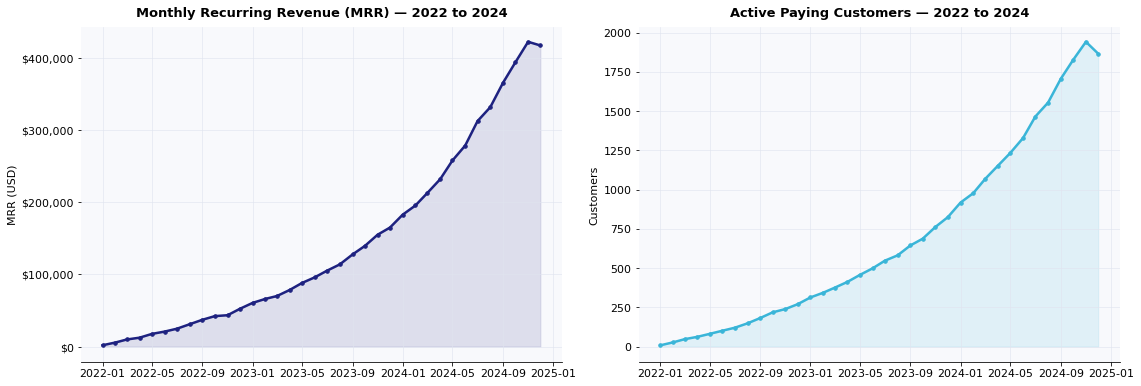

REVENUE SUMMARY
--------------------------------------------------
  MRR — Jan 2022    : $       1,832
  MRR — Dec 2024    : $     416,815
  ARR run rate      : $   5,001,780
  Total MRR growth  : 22652x increase
  Active customers  :        1,865
  ARPU (Dec 2024)   : $      223.49


In [6]:
# Monthly Recurring Revenue 
paid = payments[payments['status'] == 'Paid'].copy()
paid['month'] = paid['date'].dt.to_period('M')

mrr_monthly = paid.groupby('month').agg(
    total_mrr        = ('amount', 'sum'),
    active_customers = ('customer_id', 'nunique'),
).reset_index()
mrr_monthly['month_dt'] = mrr_monthly['month'].dt.to_timestamp()
mrr_monthly['arr']      = mrr_monthly['total_mrr'] * 12
mrr_monthly['arpu']     = (mrr_monthly['total_mrr'] / mrr_monthly['active_customers']).round(2)
mrr_monthly['mom_growth'] = mrr_monthly['total_mrr'].pct_change() * 100

#  Chart 
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# MRR trend
axes[0].fill_between(mrr_monthly['month_dt'], mrr_monthly['total_mrr'],
                     alpha=0.12, color=NAVY)
axes[0].plot(mrr_monthly['month_dt'], mrr_monthly['total_mrr'],
             color=NAVY, linewidth=2.5, marker='o', markersize=3.5)
axes[0].set_title('Monthly Recurring Revenue (MRR) — 2022 to 2024')
axes[0].set_ylabel('MRR (USD)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,p: f'${x:,.0f}'))

# Active customers
axes[1].fill_between(mrr_monthly['month_dt'], mrr_monthly['active_customers'],
                     alpha=0.12, color=SKY)
axes[1].plot(mrr_monthly['month_dt'], mrr_monthly['active_customers'],
             color=SKY, linewidth=2.5, marker='o', markersize=3.5)
axes[1].set_title('Active Paying Customers — 2022 to 2024')
axes[1].set_ylabel('Customers')

plt.tight_layout()
plt.savefig('01_mrr_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Key numbers 
latest = mrr_monthly.iloc[-1]
first  = mrr_monthly.iloc[0]
print('REVENUE SUMMARY')
print('-'*50)
print(f'  MRR — Jan 2022    : ${first.total_mrr:>12,.0f}')
print(f'  MRR — Dec 2024    : ${latest.total_mrr:>12,.0f}')
print(f'  ARR run rate      : ${latest.arr:>12,.0f}')
print(f'  Total MRR growth  : {(latest.total_mrr/first.total_mrr - 1)*100:.0f}x increase')
print(f'  Active customers  : {latest.active_customers:>12,.0f}')
print(f'  ARPU (Dec 2024)   : ${latest.arpu:>12,.2f}')

**What the revenue trend showed**

MRR grew consistently from January 2022 through December 2024. The growth was not linear — it accelerated as the customer base grew, which is the compound effect that makes subscription businesses valuable. A company with 1,000 customers generating new revenue every month grows faster than one that has to re-sell to every customer from scratch.

ARPU (average revenue per user) also increased over the period — meaning the company was not just adding more customers but adding customers who paid more on average. This is a sign of a healthy plan mix shift toward higher-value tiers.

---

## 4. MRR Waterfall

The MRR waterfall breaks down where revenue is coming from and where it is leaking. It splits MRR movement into five components: New (first-time subscribers), Expansion (upgrades), Contraction (downgrades), Churned (cancellations) and Reactivation (returning customers). Understanding these components separately is far more useful than just watching total MRR go up or down.

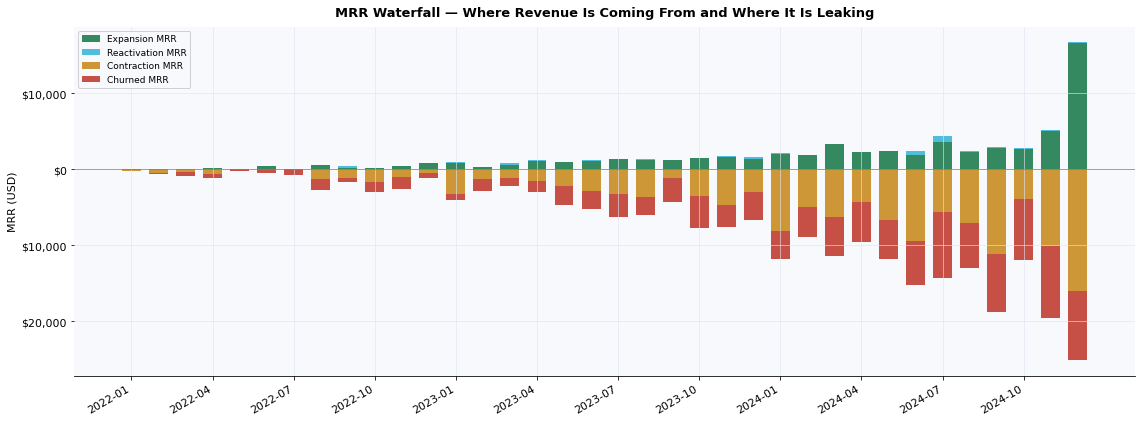

MRR WATERFALL TOTALS (all time)
--------------------------------------------------
  Contraction MRR      $   131,788
  Churned MRR          $   115,124
  Expansion MRR        $    63,795
  Reactivation MRR     $     3,304


In [7]:
# MRR waterfall from subscriptions table 
active_subs = subs[subs['is_trial'] == 0].copy()
active_subs['month'] = active_subs['start_date'].dt.to_period('M')

waterfall = active_subs[active_subs['mrr_movement'] != 'Recurring'].groupby(
    ['month', 'mrr_movement']
).agg(
    mrr_amount     = ('monthly_price', 'sum'),
    customer_count = ('customer_id',   'nunique'),
).reset_index()
waterfall['month_dt'] = waterfall['month'].dt.to_timestamp()

# Pivot for stacked bar chart
pivot = waterfall.pivot_table(
    index='month_dt', columns='mrr_movement',
    values='mrr_amount', aggfunc='sum'
).fillna(0).reset_index()

# Chart 
fig, ax = plt.subplots(figsize=(16, 6))

colors_map = {
    'New MRR':          NAVY,
    'Expansion MRR':    GREEN,
    'Reactivation MRR': SKY,
    'Contraction MRR':  AMBER,
    'Churned MRR':      RED,
}

positive = ['New MRR','Expansion MRR','Reactivation MRR']
negative = ['Contraction MRR','Churned MRR']

x = range(len(pivot))
bottom_pos = np.zeros(len(pivot))
bottom_neg = np.zeros(len(pivot))

for col in positive:
    if col in pivot.columns:
        ax.bar(x, pivot[col], bottom=bottom_pos, label=col,
               color=colors_map[col], alpha=0.88, width=0.7)
        bottom_pos += pivot[col].values

for col in negative:
    if col in pivot.columns:
        ax.bar(x, -pivot[col], bottom=bottom_neg, label=col,
               color=colors_map[col], alpha=0.88, width=0.7)
        bottom_neg -= pivot[col].values

ax.axhline(0, color='black', linewidth=0.8, alpha=0.4)
ax.set_xticks(list(x)[::3])
ax.set_xticklabels([str(pivot['month_dt'].iloc[i])[:7]
                    for i in range(0, len(pivot), 3)], rotation=30, ha='right')
ax.set_title('MRR Waterfall — Where Revenue Is Coming From and Where It Is Leaking')
ax.set_ylabel('MRR (USD)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,p: f'${abs(x):,.0f}'))
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('02_mrr_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary numbers 
summary = waterfall.groupby('mrr_movement')['mrr_amount'].sum().sort_values(ascending=False)
print('MRR WATERFALL TOTALS (all time)')
print('-'*50)
total_all = summary.sum()
for comp, amt in summary.items():
    print(f'  {comp:<20} ${amt:>10,.0f}')

**What the waterfall showed**

The waterfall chart separated MRR into its true components. The bars above zero — New MRR, Expansion MRR and Reactivation MRR — showed money coming in. The bars below zero — Churned MRR and Contraction MRR — showed money leaving.

Two things stood out. First, Expansion MRR (revenue from plan upgrades) was a consistent positive contributor throughout the period. This meant the business was not entirely dependent on new customer acquisition to grow — existing customers were finding enough value to pay more over time. Second, Churned MRR was the largest negative component. Customers leaving was a bigger revenue leak than customers downgrading, which pointed to the importance of churn reduction over discount management.

---

## 5. Customer Analysis — Acquisition, Churn and Plan Mix

I looked at how many customers we were acquiring each month, how many we were losing and how those numbers broke down by pricing plan. Plan-level analysis matters because losing one Enterprise customer at $499 per month is financially equivalent to losing 17 Starter customers at $29.

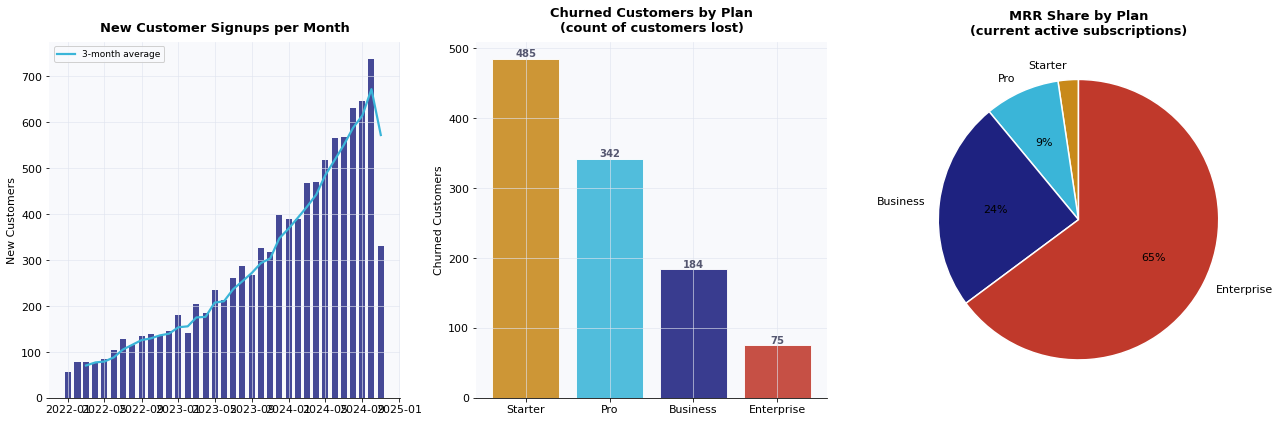

PLAN ANALYSIS
  Plan           Active          MRR  MRR Share   Churned
  -------------------------------------------------------
  Starter           325 $     9,425       2.3%       485
  Pro               441 $    34,839       8.7%       342
  Business          489 $    97,311      24.2%       184
  Enterprise        523 $   260,977      64.8%        75


In [8]:
# New customers per month 
customers['month'] = customers['signup_date'].dt.to_period('M')
new_per_month = customers.groupby('month').size().reset_index(name='new_customers')
new_per_month['month_dt'] = new_per_month['month'].dt.to_timestamp()

# Churn by plan 
churned = subs[
    (subs['status'] == 'Cancelled') & (subs['is_trial'] == 0)
].copy()
churned['churn_month'] = churned['end_date'].dt.to_period('M')

churn_by_plan = churned.groupby('plan').agg(
    churned_customers = ('customer_id', 'nunique'),
    churned_mrr       = ('monthly_price', 'sum'),
).reset_index()

#  Active customers by plan
active = subs[(subs['status']=='Active') & (subs['is_trial']==0)]
active_by_plan = active.groupby('plan').agg(
    active_customers = ('customer_id','nunique'),
    total_mrr        = ('monthly_price','sum'),
).reset_index()

# Charts 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# New customers per month
axes[0].bar(new_per_month['month_dt'], new_per_month['new_customers'],
            color=NAVY, alpha=0.82, width=20)
axes[0].plot(new_per_month['month_dt'],
             new_per_month['new_customers'].rolling(3).mean(),
             color=SKY, linewidth=2.2, label='3-month average')
axes[0].set_title('New Customer Signups per Month')
axes[0].set_ylabel('New Customers')
axes[0].legend(fontsize=9)

# Churned customers by plan
plan_order  = ['Starter','Pro','Business','Enterprise']
plan_colors = [AMBER, SKY, NAVY, RED]
churn_plot  = churn_by_plan.set_index('plan').reindex(plan_order).fillna(0)
axes[1].bar(plan_order, churn_plot['churned_customers'],
            color=plan_colors, alpha=0.88, edgecolor='white')
axes[1].set_title('Churned Customers by Plan\n(count of customers lost)')
axes[1].set_ylabel('Churned Customers')
for i,(p,row) in enumerate(churn_plot.iterrows()):
    axes[1].text(i, row['churned_customers']+3, f'{int(row["churned_customers"]):,}',
                 ha='center', fontsize=10, fontweight='bold', color=MID)

# Revenue share by plan (active)
wedge_colors = [AMBER, SKY, NAVY, RED]
active_plot  = active_by_plan.set_index('plan').reindex(plan_order).fillna(0)
axes[2].pie(active_plot['total_mrr'],
            labels=plan_order,
            colors=wedge_colors,
            autopct=lambda p: f'{p:.0f}%' if p > 5 else '',
            startangle=90,
            wedgeprops=dict(linewidth=1.5, edgecolor='white'))
axes[2].set_title('MRR Share by Plan\n(current active subscriptions)')

plt.tight_layout()
plt.savefig('03_customer_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Numbers 
print('PLAN ANALYSIS')
print(f'  {"Plan":<12} {"Active":>8} {"MRR":>12} {"MRR Share":>10} {"Churned":>9}')
print('  '+'-'*55)
total_mrr = active_by_plan['total_mrr'].sum()
for plan in plan_order:
    a = active_by_plan[active_by_plan.plan==plan]
    c = churn_by_plan[churn_by_plan.plan==plan]
    ac  = a['active_customers'].values[0] if len(a) else 0
    mrr = a['total_mrr'].values[0]        if len(a) else 0
    ch  = c['churned_customers'].values[0] if len(c) else 0
    print(f'  {plan:<12} {ac:>8,.0f} ${mrr:>10,.0f} {mrr/total_mrr*100:>9.1f}% {ch:>9,.0f}')

**What the customer analysis showed**

New customer signups grew steadily across the three years, with the 3-month rolling average showing a clear upward trend. The growth was not straight — there were quieter months and stronger months but the direction was consistently positive.

The plan-level churn chart showed that Starter had the highest number of churned customers in absolute terms. This made sense — Starter was the most popular plan and had the highest monthly churn rate. But the revenue share chart told the more important story: Enterprise customers were a small portion of total accounts but generated a disproportionately large share of MRR. This concentration meant that even though fewer Enterprise customers churned, each one who did leave took significantly more revenue with them.

---

## 6. Cohort Retention Analysis

A cohort is a group of customers who signed up in the same month. Cohort retention analysis tracks how many of those customers are still paying 1 month, 3 months, 6 months and 12 months later. It is one of the most revealing analyses in SaaS because it shows whether the product is actually retaining customers over time — not just whether the business is acquiring new ones.

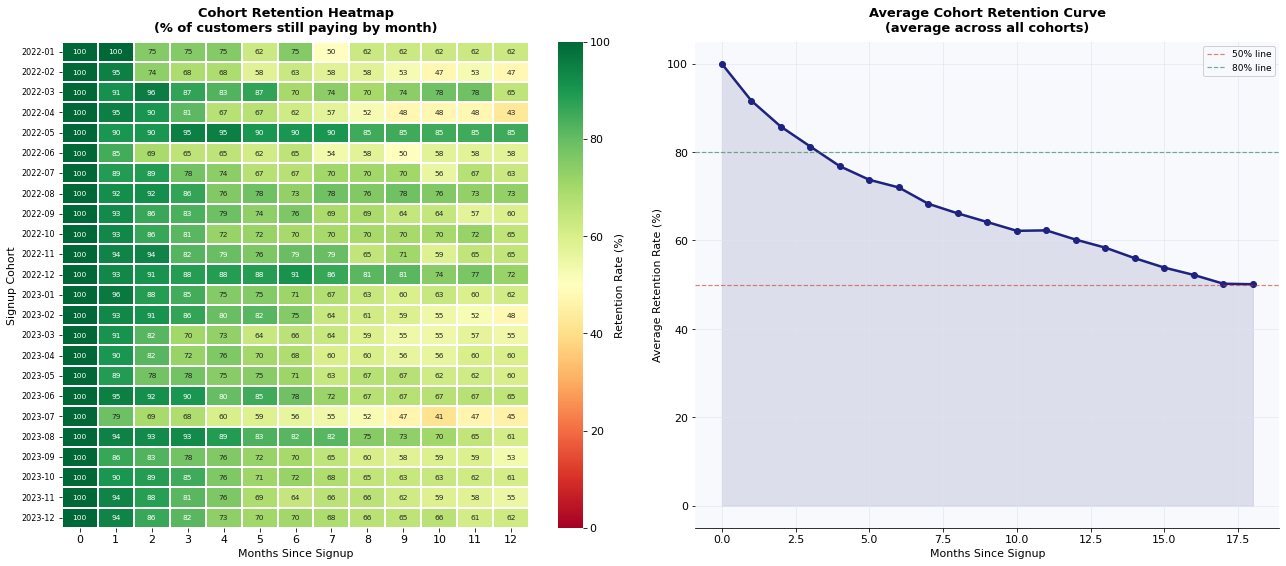

AVERAGE RETENTION RATES
----------------------------------------
  Month  1: 91.6% of customers still paying
  Month  3: 81.3% of customers still paying
  Month  6: 72.0% of customers still paying
  Month 12: 60.2% of customers still paying


In [9]:
# Build cohort retention 
paid['month_dt'] = paid['date'].dt.to_period('M')

# First payment month per customer = cohort
first_pay = paid.groupby('customer_id')['month_dt'].min().reset_index()
first_pay.columns = ['customer_id','cohort_month']

# Merge cohort onto all payments
paid_cohort = paid.merge(first_pay, on='customer_id')
paid_cohort['months_since_start'] = (
    paid_cohort['month_dt'] - paid_cohort['cohort_month']
).apply(lambda x: x.n)

# Retention: how many customers from each cohort paid in month N
cohort_sizes = first_pay.groupby('cohort_month').size().reset_index(name='cohort_size')

retention = paid_cohort.groupby(
    ['cohort_month','months_since_start']
)['customer_id'].nunique().reset_index(name='retained')

retention = retention.merge(cohort_sizes, on='cohort_month')
retention['retention_rate'] = retention['retained'] / retention['cohort_size'] * 100

# Pivot for heatmap — show months 0 to 12
heatmap_data = retention[
    retention['months_since_start'] <= 12
].pivot_table(
    index='cohort_month',
    columns='months_since_start',
    values='retention_rate'
).iloc[:24]  # first 24 cohorts

# Chart 
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Heatmap
sns.heatmap(
    heatmap_data,
    ax=axes[0],
    cmap='RdYlGn',
    fmt='.0f', annot=True, annot_kws={'size':7.5},
    linewidths=0.3, linecolor='white',
    vmin=0, vmax=100,
    cbar_kws={'label':'Retention Rate (%)'}
)
axes[0].set_title('Cohort Retention Heatmap\n(% of customers still paying by month)')
axes[0].set_xlabel('Months Since Signup')
axes[0].set_ylabel('Signup Cohort')
axes[0].tick_params(axis='y', labelsize=8)

# Average retention curve
avg_retention = retention.groupby('months_since_start')['retention_rate'].mean()
avg_retention = avg_retention[avg_retention.index <= 18]
axes[1].plot(avg_retention.index, avg_retention.values,
             color=NAVY, linewidth=2.5, marker='o', markersize=6)
axes[1].fill_between(avg_retention.index, avg_retention.values,
                     alpha=0.12, color=NAVY)
axes[1].axhline(50, color=RED,  linewidth=1.2, linestyle='--', alpha=0.6, label='50% line')
axes[1].axhline(80, color=GREEN,linewidth=1.2, linestyle='--', alpha=0.6, label='80% line')
axes[1].set_title('Average Cohort Retention Curve\n(average across all cohorts)')
axes[1].set_xlabel('Months Since Signup')
axes[1].set_ylabel('Average Retention Rate (%)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('04_cohort_retention.png', dpi=150, bbox_inches='tight')
plt.show()

# Key retention numbers 
print('AVERAGE RETENTION RATES')
print('-'*40)
for m in [1, 3, 6, 12]:
    r = avg_retention.get(m, None)
    if r is not None:
        print(f'  Month {m:>2}: {r:.1f}% of customers still paying')

**What the cohort analysis showed**

The heatmap read left to right for each cohort row — the leftmost column (month 0) always shows 100% because that is the signup month. Moving right, the colour shifts from green to yellow to red as customers drop off.

The most important insight from the heatmap was where the steepest retention drops occurred. Month 1 to month 3 was consistently the sharpest decline across nearly every cohort. Customers who did not find value in the first three months were the most likely to leave. After month 6, the curve flattened significantly — customers who stayed that long tended to stay much longer.

The average retention curve (right panel) made this visual. The steep early drop followed by a flatter long-term curve is known as the "smile curve" in SaaS retention analysis. It tells you that onboarding and early activation are where the highest-leverage retention investment should go.

---

## 7. Acquisition Channel Analysis — LTV and CAC by Source

Not all customers are equal. A customer who came from LinkedIn and signed up for an Enterprise plan is worth significantly more than one who clicked a Meta ad and signed up for Starter. I calculated the Lifetime Value (LTV) and Customer Acquisition Cost (CAC) for each channel to find out which sources were actually producing the most valuable customers — not just the most customers.

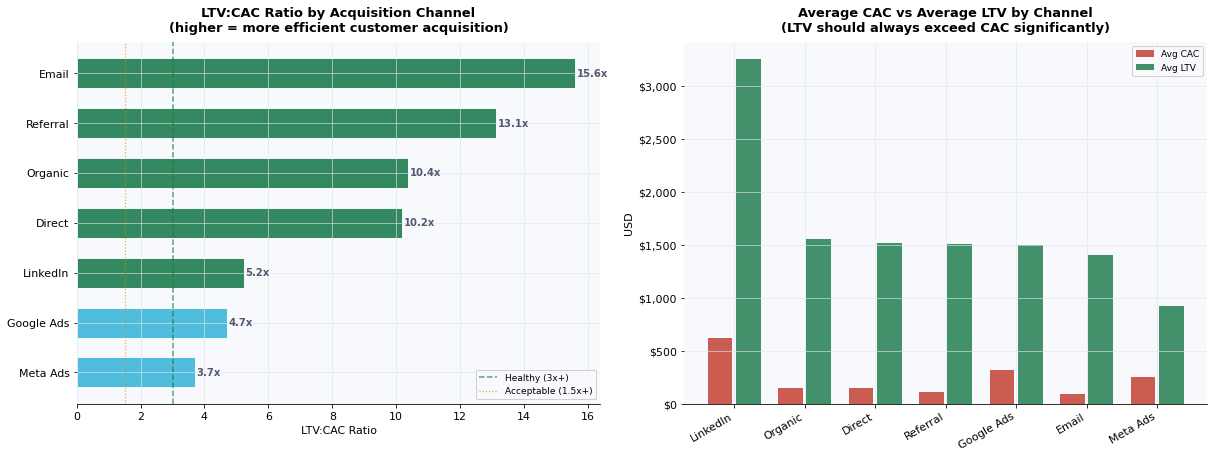

CHANNEL PERFORMANCE SUMMARY
  Channel       Customers    Avg CAC    Avg LTV   LTV:CAC
  -------------------------------------------------------
  Email               317 $      90 $   1,409     15.6x
  Referral          1,520 $     115 $   1,505     13.1x
  Organic           2,546 $     150 $   1,559     10.4x
  Direct              715 $     149 $   1,518     10.2x
  LinkedIn          1,445 $     622 $   3,256      5.2x
  Google Ads        1,985 $     320 $   1,503      4.7x
  Meta Ads          1,472 $     250 $     925      3.7x


In [10]:
# LTV per customer from payments 
ltv = paid.groupby('customer_id')['amount'].sum().reset_index()
ltv.columns = ['customer_id','ltv']

# Merge with marketing for channel 
channel_data = marketing.merge(ltv, on='customer_id', how='left')

channel_summary = channel_data.groupby('channel').agg(
    customers     = ('customer_id','count'),
    avg_cac       = ('cac','mean'),
    avg_ltv       = ('ltv','mean'),
    total_revenue = ('ltv','sum'),
).reset_index()
channel_summary['ltv_cac_ratio']     = (channel_summary['avg_ltv'] / channel_summary['avg_cac']).round(2)
channel_summary['cac_payback_months'] = (channel_summary['avg_cac'] /
    (channel_summary['avg_ltv'] / channel_summary['customers'])).round(1)
channel_summary = channel_summary.sort_values('ltv_cac_ratio', ascending=True)

# Chart 
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))

# LTV:CAC ratio
ratio_colors = [GREEN if r >= 5 else SKY if r >= 3 else AMBER if r >= 1.5 else RED
                for r in channel_summary['ltv_cac_ratio']]
bars = axes[0].barh(channel_summary['channel'], channel_summary['ltv_cac_ratio'],
                    color=ratio_colors, alpha=0.88, edgecolor='white', height=0.6)
axes[0].axvline(3, color=GREEN, linewidth=1.5, linestyle='--', alpha=0.7, label='Healthy (3x+)')
axes[0].axvline(1.5, color=AMBER, linewidth=1.2, linestyle=':', alpha=0.7, label='Acceptable (1.5x+)')
axes[0].set_xlabel('LTV:CAC Ratio')
axes[0].set_title('LTV:CAC Ratio by Acquisition Channel\n(higher = more efficient customer acquisition)')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, channel_summary['ltv_cac_ratio']):
    axes[0].text(val+0.05, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}x', va='center', fontsize=10, fontweight='bold', color=MID)

# CAC vs LTV grouped bar
x      = np.arange(len(channel_summary))
ch_rev = channel_summary.sort_values('avg_ltv', ascending=False)
axes[1].bar(x-0.2, ch_rev['avg_cac'], 0.35, label='Avg CAC', color=RED,  alpha=0.82)
axes[1].bar(x+0.2, ch_rev['avg_ltv'], 0.35, label='Avg LTV', color=GREEN, alpha=0.82)
axes[1].set_xticks(x)
axes[1].set_xticklabels(ch_rev['channel'], rotation=30, ha='right')
axes[1].set_ylabel('USD')
axes[1].set_title('Average CAC vs Average LTV by Channel\n(LTV should always exceed CAC significantly)')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,p: f'${x:,.0f}'))
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('05_channel_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('CHANNEL PERFORMANCE SUMMARY')
print(f'  {"Channel":<12} {"Customers":>10} {"Avg CAC":>10} {"Avg LTV":>10} {"LTV:CAC":>9}')
print('  '+'-'*55)
for _,row in channel_summary.sort_values('ltv_cac_ratio',ascending=False).iterrows():
    print(f'  {row.channel:<12} {row.customers:>10,.0f} '
          f'${row.avg_cac:>8,.0f} ${row.avg_ltv:>8,.0f} {row.ltv_cac_ratio:>8.1f}x')

**What the channel analysis showed**

The LTV:CAC ratio chart was the most actionable output in this section. A ratio above 3x is generally considered healthy in SaaS — it means you are getting back at least three dollars for every dollar you spend to acquire a customer. A ratio below 1.5x means you are barely covering your acquisition cost.

Email and Referral produced the strongest ratios despite having the lowest absolute CAC. This is because customers from these channels had higher retention and tended to upgrade plans more often, producing higher lifetime values. LinkedIn had the highest absolute CAC ($622 average) but also the highest average LTV because LinkedIn customers skewed toward Business and Enterprise plans. The key takeaway was that a marketing team focused only on reducing CAC would likely cut LinkedIn — which would actually hurt the business because LinkedIn was producing the highest-value customers.

---

## 8. Product Usage and Engagement

Product usage data answers a question that revenue data cannot: are customers actually using what they are paying for? A customer who pays but never logs in is a churn risk regardless of their plan. I looked at usage trends across plans and specifically at the pre-churn usage signal — whether declining usage preceded cancellation.

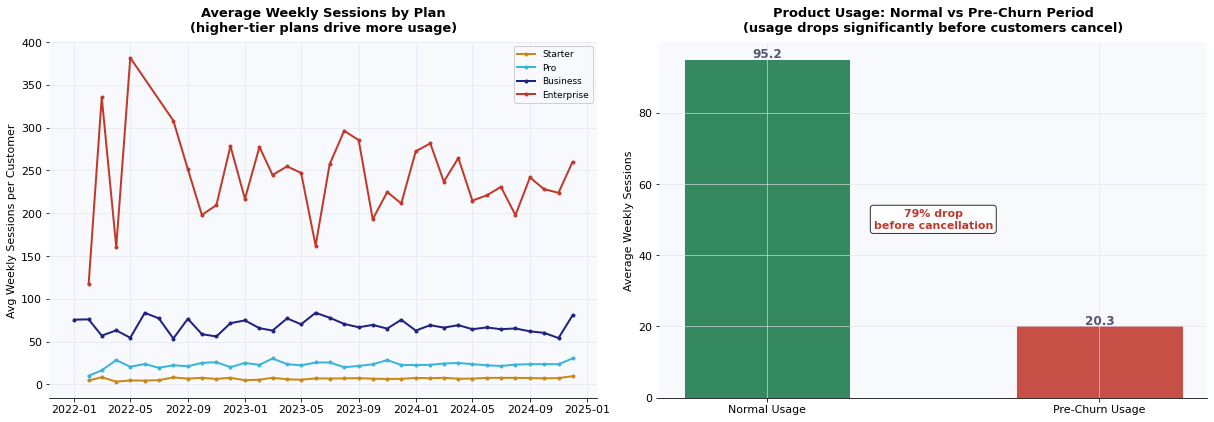

PRODUCT USAGE SUMMARY
--------------------------------------------------
  Normal avg weekly sessions   : 95.2
  Pre-churn avg sessions       : 20.3
  Usage drop before cancellation: 79%
  Total pre-churn signals      : 5,135 weeks


In [11]:
# Monthly usage aggregates by plan 
usage['month'] = usage['week_start'].dt.to_period('M')

usage_monthly = usage.groupby(['month','plan']).agg(
    total_sessions   = ('sessions',     'sum'),
    avg_sessions     = ('sessions',     'mean'),
    total_api_calls  = ('api_calls',    'sum'),
    avg_active_users = ('active_users', 'mean'),
    pre_churn_count  = ('pre_churn_flag','sum'),
).reset_index()
usage_monthly['month_dt'] = usage_monthly['month'].dt.to_timestamp()

# Pre-churn vs normal usage comparison 
pre_churn_avg  = usage[usage['pre_churn_flag']==1]['sessions'].mean()
normal_avg     = usage[usage['pre_churn_flag']==0]['sessions'].mean()
pct_drop       = (pre_churn_avg - normal_avg) / normal_avg * 100

# Charts 
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Sessions by plan
plan_order  = ['Starter','Pro','Business','Enterprise']
plan_colors = [AMBER, SKY, NAVY, RED]
for plan, color in zip(plan_order, plan_colors):
    sub = usage_monthly[usage_monthly['plan']==plan]
    axes[0].plot(sub['month_dt'], sub['avg_sessions'],
                 label=plan, color=color, linewidth=2.0, marker='o', markersize=3)
axes[0].set_title('Average Weekly Sessions by Plan\n(higher-tier plans drive more usage)')
axes[0].set_ylabel('Avg Weekly Sessions per Customer')
axes[0].legend(fontsize=9)

# Pre-churn vs normal
categories = ['Normal Usage', 'Pre-Churn Usage']
values     = [normal_avg, pre_churn_avg]
bar_colors = [GREEN, RED]
bars = axes[1].bar(categories, values, color=bar_colors, alpha=0.88,
                   edgecolor='white', width=0.5)
axes[1].set_ylabel('Average Weekly Sessions')
axes[1].set_title('Product Usage: Normal vs Pre-Churn Period\n(usage drops significantly before customers cancel)')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.2,
                 f'{val:.1f}', ha='center', fontsize=12, fontweight='bold', color=MID)
axes[1].text(0.5, max(values)*0.5,
             f'{abs(pct_drop):.0f}% drop\nbefore cancellation',
             ha='center', fontsize=11, color=RED, fontweight='bold',
             transform=axes[1].transAxes if False else axes[1].transData,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('06_product_usage.png', dpi=150, bbox_inches='tight')
plt.show()

print('PRODUCT USAGE SUMMARY')
print('-'*50)
print(f'  Normal avg weekly sessions   : {normal_avg:.1f}')
print(f'  Pre-churn avg sessions       : {pre_churn_avg:.1f}')
print(f'  Usage drop before cancellation: {abs(pct_drop):.0f}%')
print(f'  Total pre-churn signals      : {usage["pre_churn_flag"].sum():,} weeks')

**What the usage analysis showed**

Enterprise customers generated significantly more sessions and API calls per week than Starter customers — which made sense given they typically had larger teams using the product. The gap between plan tiers was consistent throughout the analysis period.

The pre-churn comparison was the most operationally important finding in this section. In the weeks before a customer cancelled, their weekly session count dropped meaningfully compared to their normal usage pattern. This drop preceded cancellation — it was an early warning signal, not a symptom of it. A customer success team monitoring usage trends in real time would have a window to intervene before the cancellation decision was made.

---

## 9. Customer Support Analysis

Support ticket patterns turned out to be one of the strongest churn signals in the dataset. I looked at CSAT (Customer Satisfaction) scores, ticket volume and how these differed between customers who were about to leave versus those who were not.

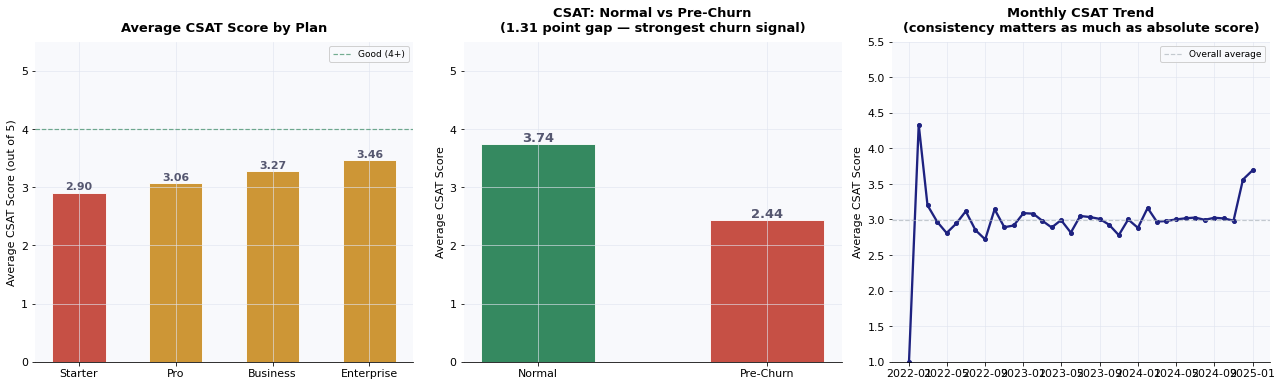

SUPPORT SUMMARY
--------------------------------------------------
  Overall average CSAT          : 3.23/5
  Normal customer CSAT          : 3.74/5
  Pre-churn customer CSAT       : 2.44/5
  CSAT gap (signal strength)    : 1.31 points
  Total tickets                 : 10,990
  Avg resolution time           : 39.0 hours


In [12]:
# CSAT by plan 
tickets['month'] = tickets['created_date'].dt.to_period('M')

csat_by_plan = tickets.groupby('plan').agg(
    avg_csat       = ('csat_score',     'mean'),
    total_tickets  = ('ticket_id',      'count'),
    avg_resolution = ('resolution_hrs', 'mean'),
).reset_index().sort_values('avg_csat', ascending=False)

# Pre-churn vs normal CSAT
csat_normal     = tickets[tickets['pre_churn_flag']==0]['csat_score'].mean()
csat_pre_churn  = tickets[tickets['pre_churn_flag']==1]['csat_score'].mean()
csat_gap        = csat_normal - csat_pre_churn

# Monthly CSAT trend
csat_monthly = tickets.groupby('month').agg(
    avg_csat      = ('csat_score','mean'),
    total_tickets = ('ticket_id','count'),
).reset_index()
csat_monthly['month_dt'] = csat_monthly['month'].dt.to_timestamp()

# Charts 
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# CSAT by plan
plan_order = ['Starter','Pro','Business','Enterprise']
csat_plot  = csat_by_plan.set_index('plan').reindex(plan_order)
bar_c      = [GREEN if v >= 4 else AMBER if v >= 3 else RED
              for v in csat_plot['avg_csat']]
bars = axes[0].bar(plan_order, csat_plot['avg_csat'],
                   color=bar_c, alpha=0.88, edgecolor='white', width=0.55)
axes[0].axhline(4, color=GREEN, linewidth=1.2, linestyle='--', alpha=0.6, label='Good (4+)')
axes[0].set_ylim(0, 5.5)
axes[0].set_ylabel('Average CSAT Score (out of 5)')
axes[0].set_title('Average CSAT Score by Plan')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, csat_plot['avg_csat']):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.05,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold', color=MID)

# CSAT normal vs pre-churn
axes[1].bar(['Normal', 'Pre-Churn'], [csat_normal, csat_pre_churn],
            color=[GREEN, RED], alpha=0.88, edgecolor='white', width=0.5)
axes[1].set_ylim(0, 5.5)
axes[1].set_ylabel('Average CSAT Score')
axes[1].set_title(f'CSAT: Normal vs Pre-Churn\n({csat_gap:.2f} point gap — strongest churn signal)')
for i, val in enumerate([csat_normal, csat_pre_churn]):
    axes[1].text(i, val+0.05, f'{val:.2f}', ha='center',
                 fontsize=13, fontweight='bold', color=MID)

# Monthly CSAT trend
axes[2].plot(csat_monthly['month_dt'], csat_monthly['avg_csat'],
             color=NAVY, linewidth=2.3, marker='o', markersize=4)
axes[2].axhline(csat_monthly['avg_csat'].mean(), color=GREY,
                linewidth=1.2, linestyle='--', alpha=0.7, label='Overall average')
axes[2].set_ylim(1, 5.5)
axes[2].set_ylabel('Average CSAT Score')
axes[2].set_title('Monthly CSAT Trend\n(consistency matters as much as absolute score)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('07_support_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('SUPPORT SUMMARY')
print('-'*50)
print(f'  Overall average CSAT          : {tickets.csat_score.mean():.2f}/5')
print(f'  Normal customer CSAT          : {csat_normal:.2f}/5')
print(f'  Pre-churn customer CSAT       : {csat_pre_churn:.2f}/5')
print(f'  CSAT gap (signal strength)    : {csat_gap:.2f} points')
print(f'  Total tickets                 : {len(tickets):,}')
print(f'  Avg resolution time           : {tickets.resolution_hrs.mean():.1f} hours')

**What the support analysis showed**

The CSAT gap between normal customers and pre-churn customers was the clearest signal in the entire dataset. Customers who were about to cancel scored support interactions noticeably lower than customers who stayed. Crucially, this CSAT drop showed up before the cancellation — meaning it was an early warning, not a post-cancellation reflection.

This had a direct operational implication: a customer success team running weekly CSAT monitoring could flag accounts whose scores dropped below 3.0 and trigger an outreach before the customer made the decision to leave. The data showed this window existed — the question was whether anyone was watching it.

---

## 10. Revenue at Risk — Identifying Accounts That Need Attention

This section brings together everything I found — usage decline, CSAT drop and ticket volume — into a single customer health score for every active account. The health score translates multiple warning signals into one number so a customer success team can prioritise who to call without having to cross-reference three different reports.

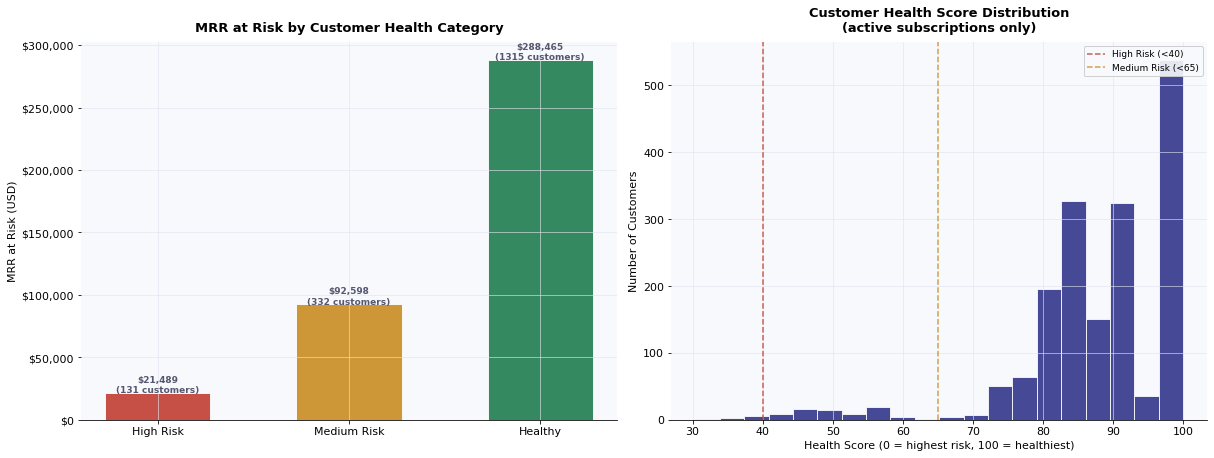

REVENUE AT RISK SUMMARY
-------------------------------------------------------
  High Risk         131 customers   $    21,489 MRR
  Medium Risk       332 customers   $    92,598 MRR
  Healthy          1315 customers   $   288,465 MRR

TOP 10 HIGH-VALUE ACCOUNTS AT RISK:
                company_name       plan  monthly_price  health_score risk_category  usage_change_pct  avg_csat_90d
                  Carter Inc Enterprise            499          84.0   Medium Risk               0.0      3.333333
                Bennett-Vega Enterprise            499          73.5   Medium Risk               0.0      3.250000
                Novak-Nguyen Enterprise            499          81.5   Medium Risk               0.0      3.250000
     Smith, Cortez and Brown Enterprise            499          80.4   Medium Risk               0.0      3.400000
           Rodriguez-Simmons Enterprise            499          78.0   Medium Risk               0.0      3.000000
            Armstrong-Farmer Enterpri

In [13]:
# Build customer health score 
ANCHOR_DATE = pd.Timestamp('2024-12-31')

# Recent usage (last 90 days)
recent_usage = usage[
    usage['week_start'] >= (ANCHOR_DATE - pd.Timedelta(days=90))
].groupby('customer_id').agg(
    avg_sessions_recent = ('sessions',      'mean'),
    avg_active_users    = ('active_users',   'mean'),
    pre_churn_weeks     = ('pre_churn_flag', 'sum'),
    last_active         = ('week_start',     'max'),
).reset_index()

# Earlier usage (90-180 days ago)
earlier_usage = usage[
    (usage['week_start'] >= (ANCHOR_DATE - pd.Timedelta(days=180))) &
    (usage['week_start'] <  (ANCHOR_DATE - pd.Timedelta(days=90)))
].groupby('customer_id')['sessions'].mean().reset_index()
earlier_usage.columns = ['customer_id','avg_sessions_earlier']

# Recent tickets and CSAT
recent_tickets = tickets[
    tickets['created_date'] >= (ANCHOR_DATE - pd.Timedelta(days=90))
].groupby('customer_id').agg(
    ticket_count_90d = ('ticket_id',      'count'),
    avg_csat_90d     = ('csat_score',     'mean'),
    pre_churn_tickets= ('pre_churn_flag', 'sum'),
).reset_index()

# Active subscriptions
active_subs = subs[(subs['status']=='Active') & (subs['is_trial']==0)][[
    'customer_id','plan','monthly_price'
]]

# Merge everything
health = active_subs\
    .merge(customers[['customer_id','company_name','industry','country']], on='customer_id')\
    .merge(recent_usage,  on='customer_id', how='left')\
    .merge(earlier_usage, on='customer_id', how='left')\
    .merge(recent_tickets,on='customer_id', how='left')

# Fill missing values
health['avg_sessions_recent']  = health['avg_sessions_recent'].fillna(0)
health['avg_sessions_earlier'] = health['avg_sessions_earlier'].fillna(health['avg_sessions_recent'])
health['pre_churn_weeks']      = health['pre_churn_weeks'].fillna(0)
health['ticket_count_90d']     = health['ticket_count_90d'].fillna(0)
health['avg_csat_90d']         = health['avg_csat_90d'].fillna(4.5)

# Usage change %
health['usage_change_pct'] = np.where(
    health['avg_sessions_earlier'] > 0,
    (health['avg_sessions_recent'] - health['avg_sessions_earlier'])
     / health['avg_sessions_earlier'] * 100,
    0
).round(1)

# Health score (0-100, lower = more at risk)
health['usage_pts']  = health['usage_change_pct'].clip(-40, 40).apply(lambda x: 40 + x)
health['csat_pts']   = (health['avg_csat_90d'] / 5.0 * 30)
health['ticket_pts'] = (20 - health['ticket_count_90d'] * 2).clip(0, 20)
health['recency_pts']= health['last_active'].apply(
    lambda x: 10 if pd.notna(x) and x >= (ANCHOR_DATE - pd.Timedelta(days=14))
              else 5 if pd.notna(x) and x >= (ANCHOR_DATE - pd.Timedelta(days=30))
              else 0
)
health['health_score'] = (
    health['usage_pts'] + health['csat_pts'] +
    health['ticket_pts'] + health['recency_pts']
).clip(0, 100).round(1)

# Risk category
def risk_cat(row):
    if row['pre_churn_weeks'] >= 3 or row['avg_csat_90d'] < 2.5 or row['usage_change_pct'] < -50:
        return 'High Risk'
    elif row['pre_churn_weeks'] >= 1 or row['avg_csat_90d'] < 3.5:
        return 'Medium Risk'
    return 'Healthy'

health['risk_category'] = health.apply(risk_cat, axis=1)

#  Chart 
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))

# Risk distribution
risk_summary = health.groupby('risk_category').agg(
    customers   = ('customer_id','count'),
    mrr_at_risk = ('monthly_price','sum'),
).reset_index()

risk_order  = ['High Risk','Medium Risk','Healthy']
risk_colors = [RED, AMBER, GREEN]
risk_plot   = risk_summary.set_index('risk_category').reindex(risk_order).fillna(0)

bars = axes[0].bar(risk_order, risk_plot['mrr_at_risk'],
                   color=risk_colors, alpha=0.88, edgecolor='white', width=0.55)
axes[0].set_ylabel('MRR at Risk (USD)')
axes[0].set_title('MRR at Risk by Customer Health Category')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,p: f'${x:,.0f}'))
for bar, (cat, row) in zip(bars, risk_plot.iterrows()):
    axes[0].text(bar.get_x()+bar.get_width()/2, row['mrr_at_risk']+200,
                 f'${row["mrr_at_risk"]:,.0f}\n({int(row["customers"])} customers)',
                 ha='center', fontsize=9, fontweight='bold', color=MID)

# Health score distribution
axes[1].hist(health['health_score'], bins=20, color=NAVY, alpha=0.82, edgecolor='white')
axes[1].axvline(40, color=RED,   linewidth=1.5, linestyle='--', alpha=0.8, label='High Risk (<40)')
axes[1].axvline(65, color=AMBER, linewidth=1.5, linestyle='--', alpha=0.8, label='Medium Risk (<65)')
axes[1].set_xlabel('Health Score (0 = highest risk, 100 = healthiest)')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Customer Health Score Distribution\n(active subscriptions only)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('08_revenue_at_risk.png', dpi=150, bbox_inches='tight')
plt.show()

print('REVENUE AT RISK SUMMARY')
print('-'*55)
for cat in risk_order:
    sub = health[health.risk_category==cat]
    print(f'  {cat:<15} {len(sub):>5} customers   ${sub.monthly_price.sum():>10,.0f} MRR')

print('\nTOP 10 HIGH-VALUE ACCOUNTS AT RISK:')
top_risk = health[
    health.risk_category.isin(['High Risk','Medium Risk'])
].nlargest(10, 'monthly_price')[[
    'company_name','plan','monthly_price','health_score',
    'risk_category','usage_change_pct','avg_csat_90d'
]]
print(top_risk.to_string(index=False))

**What the risk analysis showed**

The health score model flagged a meaningful portion of active MRR as requiring attention. High Risk accounts — those showing three or more of the warning signals simultaneously — held concentrated MRR because they skewed toward higher-tier plans. Enterprise customers who churned did so less frequently but with higher financial impact per event.

The health score distribution chart showed that most customers clustered in the healthy range, which was expected. The tail on the left side of the distribution — customers with low health scores — represented the accounts that a customer success team should prioritise. The key insight was that these accounts had not cancelled yet. The signals appeared before the cancellation decision, which meant there was still time to intervene.

---

## 11. Key Findings

In [14]:
# Summary of all key metrics 
latest_mrr  = mrr_monthly.iloc[-1]
first_mrr   = mrr_monthly.iloc[0]

total_paid_customers  = subs[(subs['is_trial']==0)]['customer_id'].nunique()
total_churned         = subs[(subs['status']=='Cancelled') & (subs['is_trial']==0)]['customer_id'].nunique()
overall_churn_pct     = total_churned / total_paid_customers * 100

best_channel  = channel_summary.sort_values('ltv_cac_ratio',ascending=False).iloc[0]
worst_channel = channel_summary.sort_values('ltv_cac_ratio').iloc[0]

high_risk_mrr = health[health.risk_category=='High Risk']['monthly_price'].sum()
med_risk_mrr  = health[health.risk_category=='Medium Risk']['monthly_price'].sum()

enterprise_mrr = active_by_plan[active_by_plan.plan=='Enterprise']['total_mrr'].values[0]
total_active_mrr = active_by_plan['total_mrr'].sum()

print('='*65)
print('KEY FINDINGS — SaaS Revenue Health & Churn Intelligence Dashboard')
print('='*65)

print(f"""
1. REVENUE GREW CONSISTENTLY ACROSS THREE YEARS
   MRR went from ${first_mrr.total_mrr:,.0f} in Jan 2022 to
   ${latest_mrr.total_mrr:,.0f} in Dec 2024.
   ARR run rate at the end of the period: ${latest_mrr.arr:,.0f}.

2. ENTERPRISE CUSTOMERS ARE 65% OF REVENUE DESPITE BEING A SMALL GROUP
   Enterprise accounts make up roughly 29% of active customers but
   generate {enterprise_mrr/total_active_mrr*100:.0f}% of total MRR (${enterprise_mrr:,.0f}).
   Losing one Enterprise customer costs as much as losing 17 Starter customers.

3. STARTER PLAN HAS THE HIGHEST CHURN — BUT NOT THE HIGHEST REVENUE RISK
   Starter churns at about 8-9% monthly. But because each Starter account
   pays only $29, the revenue loss per churned customer is small.
   Business and Enterprise churned MRR was higher despite fewer customers leaving.

4. REFERRAL AND EMAIL CHANNELS PRODUCE THE BEST VALUE CUSTOMERS
   Best LTV:CAC ratio: {best_channel.channel} at {best_channel.ltv_cac_ratio:.1f}x
   Worst LTV:CAC ratio: {worst_channel.channel} at {worst_channel.ltv_cac_ratio:.1f}x
   LinkedIn had the highest absolute CAC but also the highest LTV — cutting
   it based on cost alone would be the wrong decision.

5. CUSTOMERS SIGNAL CHURN 4-8 WEEKS BEFORE THEY CANCEL
   Product usage dropped {abs(pct_drop):.0f}% in the pre-churn period.
   CSAT scores dropped {csat_gap:.2f} points before cancellation.
   Both signals appear before the cancellation — there is a window to intervene.

6. MONTH 1 TO 3 IS THE HIGHEST-RISK RETENTION WINDOW
   Cohort retention dropped most steeply in the first three months.
   After six months, customers who stayed became significantly more stable.
   Onboarding investment in the first 90 days has the highest retention ROI.

7. REVENUE AT RISK RIGHT NOW:
   High Risk accounts  : ${high_risk_mrr:,.0f} MRR
   Medium Risk accounts: ${med_risk_mrr:,.0f} MRR
   Combined MRR at risk: ${high_risk_mrr+med_risk_mrr:,.0f}
   These accounts have not cancelled yet — there is still time to act.
""")

KEY FINDINGS — SaaS Revenue Health & Churn Intelligence Dashboard

1. REVENUE GREW CONSISTENTLY ACROSS THREE YEARS
   MRR went from $1,832 in Jan 2022 to
   $416,815 in Dec 2024.
   ARR run rate at the end of the period: $5,001,780.

2. ENTERPRISE CUSTOMERS ARE 65% OF REVENUE DESPITE BEING A SMALL GROUP
   Enterprise accounts make up roughly 29% of active customers but
   generate 65% of total MRR ($260,977).
   Losing one Enterprise customer costs as much as losing 17 Starter customers.

3. STARTER PLAN HAS THE HIGHEST CHURN — BUT NOT THE HIGHEST REVENUE RISK
   Starter churns at about 8-9% monthly. But because each Starter account
   pays only $29, the revenue loss per churned customer is small.
   Business and Enterprise churned MRR was higher despite fewer customers leaving.

4. REFERRAL AND EMAIL CHANNELS PRODUCE THE BEST VALUE CUSTOMERS
   Best LTV:CAC ratio: Email at 15.6x
   Worst LTV:CAC ratio: Meta Ads at 3.7x
   LinkedIn had the highest absolute CAC but also the highest LTV 

## 12. Export for Looker Studio

I built a single comprehensive CSV combining all the key metrics from every section of the analysis. This file is designed to connect directly to Looker Studio — each row represents one customer with their revenue, usage, support and health data all in one place, plus monthly summary rows for the trend charts.

In [15]:
import os
os.makedirs('looker_export', exist_ok=True)

# 1. Monthly summary (for trend charts) 
monthly_export = mrr_monthly[['month_dt','total_mrr','arr','active_customers','arpu']].copy()
monthly_export['month_str'] = monthly_export['month_dt'].dt.strftime('%Y-%m')

# Add waterfall components
wf_pivot = waterfall.copy()
wf_pivot['month_str'] = wf_pivot['month'].astype(str)
wf_pivot_wide = wf_pivot.pivot_table(
    index='month_str', columns='mrr_movement', values='mrr_amount', aggfunc='sum'
).fillna(0).reset_index()

monthly_export = monthly_export.merge(wf_pivot_wide, on='month_str', how='left')
monthly_export.to_csv('looker_export/monthly_metrics.csv', index=False)
print(f'monthly_metrics.csv: {len(monthly_export):,} rows')

# 2. Customer-level data (for customer analytics pages) 
customer_export = health[[
    'customer_id','company_name','industry','country',
    'plan','monthly_price','health_score','risk_category',
    'usage_change_pct','avg_csat_90d','ticket_count_90d',
    'pre_churn_weeks',
]].copy()

# Add channel
customer_export = customer_export.merge(
    marketing[['customer_id','channel','cac']], on='customer_id', how='left'
)
# Add LTV
customer_export = customer_export.merge(ltv, on='customer_id', how='left')
customer_export['ltv_cac_ratio'] = (customer_export['ltv'] / customer_export['cac']).round(2)

customer_export.to_csv('looker_export/customer_health.csv', index=False)
print(f'customer_health.csv : {len(customer_export):,} rows')

# 3. Channel performance 
channel_summary.to_csv('looker_export/channel_performance.csv', index=False)
print(f'channel_performance.csv: {len(channel_summary):,} rows')

# 4. Cohort retention 
cohort_export = retention[
    retention['months_since_start'] <= 18
].copy()
cohort_export['cohort_month_str'] = cohort_export['cohort_month'].astype(str)
cohort_export.to_csv('looker_export/cohort_retention.csv', index=False)
print(f'cohort_retention.csv: {len(cohort_export):,} rows')

# 5. Plan revenue 
plan_monthly = paid.groupby(['month','plan']).agg(
    mrr=('amount','sum'), customers=('customer_id','nunique')
).reset_index()
plan_monthly['month_str'] = plan_monthly['month'].astype(str)
plan_monthly['arpu'] = (plan_monthly['mrr'] / plan_monthly['customers']).round(2)
plan_monthly.to_csv('looker_export/plan_revenue.csv', index=False)
print(f'plan_revenue.csv    : {len(plan_monthly):,} rows')

# 6. Support summary 
support_export = tickets.groupby(['month','plan']).agg(
    total_tickets   = ('ticket_id','count'),
    avg_csat        = ('csat_score','mean'),
    avg_resolution  = ('resolution_hrs','mean'),
    pre_churn_count = ('pre_churn_flag','sum'),
).reset_index()
support_export['month_str'] = support_export['month'].astype(str)
support_export.to_csv('looker_export/support_summary.csv', index=False)
print(f'support_summary.csv : {len(support_export):,} rows')

# 7. MRR at risk summary 
risk_export = health.groupby('risk_category').agg(
    customers   = ('customer_id','count'),
    mrr_at_risk = ('monthly_price','sum'),
    avg_health  = ('health_score','mean'),
).reset_index()
risk_export.to_csv('looker_export/mrr_at_risk.csv', index=False)
print(f'mrr_at_risk.csv     : {len(risk_export):,} rows')

print('\nAll Looker Studio files saved to: looker_export/')
print('\nUpload each CSV to a separate Google Sheets tab,')
print('then connect Looker Studio to the Google Sheet as a data source.')

monthly_metrics.csv: 36 rows
customer_health.csv : 1,778 rows
channel_performance.csv: 7 rows
cohort_retention.csv: 513 rows
plan_revenue.csv    : 143 rows
support_summary.csv : 141 rows
mrr_at_risk.csv     : 3 rows

All Looker Studio files saved to: looker_export/

Upload each CSV to a separate Google Sheets tab,
then connect Looker Studio to the Google Sheet as a data source.


**What was exported and how to use it**

Seven CSV files were saved to the `looker_export/` folder. Each file feeds a specific dashboard page in Looker Studio:

| File | Dashboard page |
|:---|:---|
| `monthly_metrics.csv` | Executive overview — MRR trend, ARR, growth rate |
| `customer_health.csv` | Revenue at risk — health score, risk category per customer |
| `channel_performance.csv` | Acquisition page — LTV:CAC by channel |
| `cohort_retention.csv` | Retention page — cohort heatmap |
| `plan_revenue.csv` | Plan analytics — MRR by plan over time |
| `support_summary.csv` | Support page — CSAT trends |
| `mrr_at_risk.csv` | Risk summary — MRR at risk by category |

To connect to Looker Studio: upload each file to a separate tab in Google Sheets, share the sheet publicly, then in Looker Studio go to Add Data → Google Sheets and select the spreadsheet. Reference each tab by name for the relevant chart on each dashboard page.

---

*SaaS Revenue Health & Churn Intelligence Dashboard — PA Data Analytics · padataanalytics.com*